In [86]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_blobs

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN, HDBSCAN, AffinityPropagation
from sklearn.mixture import GaussianMixture

from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import silhouette_score

# Загрузка и подготовка синтетических данных

In [80]:
dataset_1 = make_classification(n_samples=2000, n_features=10)
dataset_2 = make_blobs(n_samples=300, n_features=2, centers=5)

X_1, y_1 = dataset_1
X_2, _ = dataset_2

In [81]:
scaler = StandardScaler()
X_1 = scaler.fit_transform(X_1)
X_2 = scaler.fit_transform(X_2)

# Решение задачи кластеризации

## K-means

In [67]:
WSS = []
silhouette_scores = []

In [68]:
for i in range(2, 15):
    km = KMeans(n_clusters=i).fit(X_2)
    WSS.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_2, km.labels_))


### Метод локтя

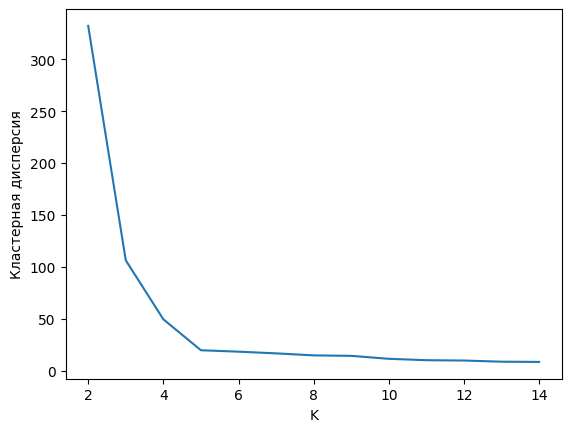

In [69]:
plt.plot(range(2, 15), WSS)
plt.xlabel("K")
plt.ylabel('Кластерная дисперсия')
plt.show()

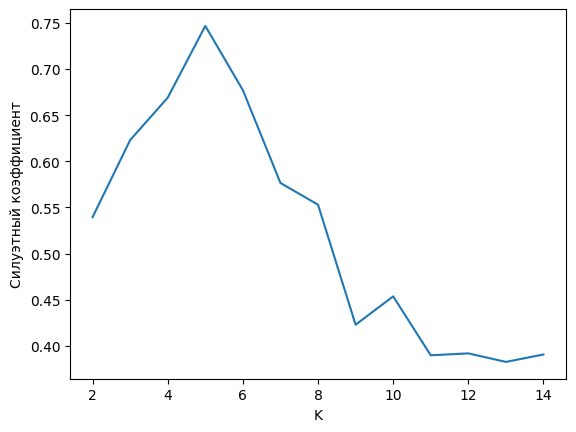

In [70]:
plt.plot(range(2, 15), silhouette_scores)
plt.xlabel("K")
plt.ylabel('Силуэтный коэффициент')
plt.show()

In [73]:
km = KMeans(n_clusters=5).fit(X_2)

In [74]:
km.labels_

array([1, 3, 0, 1, 2, 2, 0, 1, 0, 0, 4, 1, 1, 3, 1, 0, 2, 4, 2, 0, 2, 2,
       2, 3, 0, 4, 2, 4, 0, 3, 0, 4, 2, 0, 1, 0, 1, 0, 2, 1, 2, 2, 4, 0,
       4, 4, 1, 4, 0, 4, 0, 1, 1, 3, 0, 1, 3, 1, 4, 3, 1, 0, 1, 1, 1, 4,
       3, 1, 4, 3, 0, 1, 3, 0, 3, 0, 4, 3, 3, 4, 1, 3, 2, 4, 2, 0, 0, 1,
       4, 4, 2, 1, 4, 3, 1, 4, 1, 3, 4, 3, 2, 0, 3, 1, 0, 0, 0, 2, 4, 4,
       4, 0, 0, 1, 0, 4, 1, 4, 2, 3, 3, 3, 2, 2, 3, 0, 4, 2, 2, 4, 0, 1,
       3, 1, 1, 2, 3, 2, 2, 3, 3, 1, 4, 2, 2, 0, 0, 0, 3, 3, 3, 3, 3, 0,
       3, 2, 1, 0, 2, 3, 3, 2, 0, 3, 3, 4, 1, 4, 4, 2, 1, 4, 2, 3, 0, 2,
       0, 4, 1, 3, 2, 3, 1, 1, 0, 2, 2, 4, 2, 4, 1, 4, 4, 1, 4, 2, 0, 1,
       3, 1, 0, 1, 2, 1, 2, 2, 3, 2, 1, 3, 0, 4, 1, 3, 4, 2, 0, 3, 0, 4,
       3, 3, 0, 4, 1, 3, 0, 1, 4, 1, 3, 1, 2, 1, 3, 0, 1, 3, 1, 0, 4, 0,
       2, 2, 2, 2, 4, 4, 3, 0, 4, 0, 0, 4, 1, 4, 4, 2, 4, 1, 1, 4, 3, 2,
       4, 0, 2, 1, 4, 2, 4, 2, 3, 2, 3, 2, 3, 3, 4, 3, 2, 0, 2, 0, 1, 0,
       4, 0, 3, 0, 2, 4, 1, 0, 2, 4, 3, 1, 2, 3], d

In [75]:
silhouette_score(X_2, km.labels_)

0.7466921102049953

## DBSCAN

In [84]:
dbscan = DBSCAN(min_samples=4).fit(X_2)

In [85]:
dbscan.labels_

array([0, 1, 0, 2, 1, 0, 0, 0, 1, 1, 0, 0, 2, 1, 2, 1, 0, 0, 1, 1, 2, 1,
       1, 1, 2, 0, 2, 1, 0, 0, 2, 1, 0, 1, 0, 2, 1, 0, 1, 0, 2, 0, 1, 0,
       0, 0, 0, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 2, 1, 0, 1, 0, 0, 2, 0, 1, 2, 0,
       1, 2, 0, 0, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0,
       2, 1, 1, 1, 1, 0, 2, 2, 0, 0, 1, 1, 0, 1, 1, 0, 2, 1, 0, 2, 1, 2,
       0, 1, 0, 0, 1, 1, 0, 2, 0, 0, 0, 1, 2, 1, 2, 1, 2, 0, 1, 0, 2, 0,
       0, 1, 0, 0, 1, 1, 0, 2, 2, 0, 0, 1, 1, 1, 0, 0, 2, 1, 0, 1, 1, 0,
       0, 1, 2, 1, 0, 0, 0, 0, 0, 1, 0, 1, 2, 0, 0, 2, 0, 1, 2, 0, 0, 0,
       2, 0, 2, 0, 1, 2, 0, 1, 1, 0, 0, 1, 0, 1, 2, 2, 1, 0, 0, 0, 2, 1,
       0, 0, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 2, 1, 1, 1, 2, 1, 0, 1, 2, 0,
       0, 2, 0, 1, 2, 2, 1, 1, 2, 1, 1, 2, 0, 2, 0, 1, 0, 1, 1, 2, 0, 2,
       1, 1, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       2, 0, 2, 1, 1, 1, 0, 1, 1, 1, 2, 1, 0, 0])

Минимальное количество точек в окрестности часто берут как 2 * размерность (в нашем случае - 4)

Далее для каждой точки считают расстояния до k ближайших соседей (k в данном случае равно 4), считая за первого соседа саму точку (иногда не считают саму точку за первого соседа - как захочет исследователь). Полученные значения усредняют

Усредненные значения сортируют по возрастанию и отображают на графике. Знакомая вам локтевая точка (она определяется исследователем по виду графика) может указать на значение эпсилон (это будет координата y)

In [87]:
nn = NearestNeighbors(n_neighbors=4)
nn.fit(X_2)
distances, indices = nn.kneighbors(X_2)

In [89]:
mean_distances = np.mean(distances, axis=1)

In [94]:
mean_distances = np.sort(mean_distances)

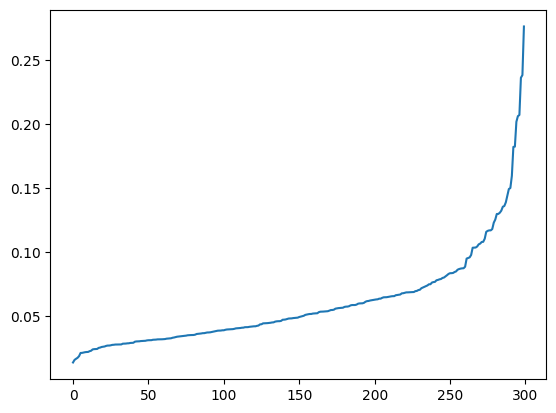

In [96]:
plt.plot(mean_distances)
plt.show()

In [ ]:
dbscan = DBSCAN(eps=0.1, min_samples=4).fit(X_2)

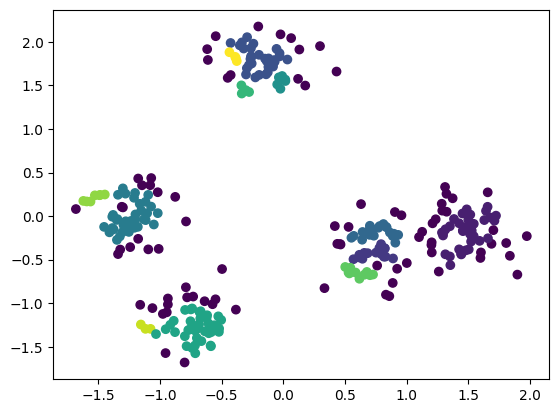

In [107]:
plt.scatter(X_2[:, 0], X_2[:, 1], c=dbscan.labels_)
plt.show()

In [108]:
silhouette_score(X_2, dbscan.labels_)

0.09339006204120712

In [109]:
dbscan = DBSCAN(eps=0.2, min_samples=4).fit(X_2)

In [110]:
silhouette_score(X_2, dbscan.labels_)

0.6701589941062591

## HDBSCAN

In [111]:
hdbscan = HDBSCAN(min_samples=4).fit(X_2)

In [112]:
hdbscan.labels_

array([1, 2, 1, 0, 2, 1, 1, 1, 3, 3, 1, 1, 0, 3, 0, 3, 1, 1, 3, 2, 0, 3,
       2, 2, 0, 1, 0, 3, 1, 1, 0, 2, 1, 2, 1, 0, 3, 1, 3, 1, 0, 1, 2, 1,
       1, 1, 1, 0, 2, 1, 3, 2, 3, 2, 2, 2, 2, 1, 3, 3, 3, 1, 3, 1, 1, 1,
       2, 3, 3, 2, 2, 3, 1, 0, 3, 2, 1, 0, 2, 1, 3, 1, 1, 0, 1, 2, 0, 1,
       2, 0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 1, 3, 1, 1, 3, 3, 2, 1, 3, 2, 1,
       0, 3, 3, 2, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 1, 0, 3, 1, 0, 2, 0,
       1, 2, 1, 1, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 0, 3, 0, 1, 2, 1, 0, 1,
       1, 3, 1, 1, 3, 3, 1, 0, 0, 1, 1, 3, 3, 2, 1, 1, 0, 3, 1, 2, 3, 1,
       1, 3, 0, 2, 1, 1, 1, 1, 1, 2, 1, 3, 0, 1, 1, 0, 1, 3, 0, 1, 1, 1,
       0, 1, 0, 1, 2, 0, 1, 3, 3, 1, 1, 2, 1, 2, 0, 0, 2, 1, 1, 1, 0, 2,
       1, 1, 1, 1, 3, 3, 0, 2, 0, 0, 3, 1, 0, 3, 3, 3, 0, 3, 1, 3, 0, 1,
       1, 0, 1, 2, 0, 0, 3, 3, 0, 2, 3, 0, 1, 0, 1, 3, 1, 3, 2, 0, 1, 0,
       3, 3, 1, 0, 0, 1, 1, 1, 1, 1, 2, 1, 3, 1, 2, 2, 1, 1, 2, 2, 2, 1,
       0, 1, 0, 2, 3, 2, 1, 3, 2, 3, 0, 3, 1, 1])

In [114]:
silhouette_score(X_2, hdbscan.labels_)

0.7399572903221314

## GaussianMixture

In [150]:
loglikelihoods  = []
silhouette_scores = []

In [151]:
for i in range(2, 15):
    gm = GaussianMixture(n_components=i).fit(X_2)
    loglikelihoods.append(gm.score(X_2))
    silhouette_scores.append(silhouette_score(X_2, gm.predict(X_2)))


### Метод локтя

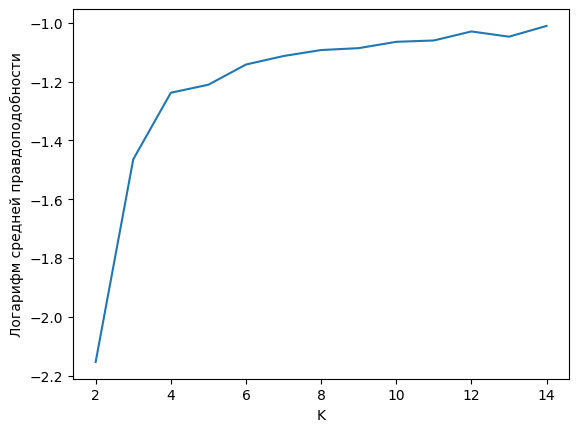

In [152]:
plt.plot(range(2, 15), loglikelihoods)
plt.xlabel("K")
plt.ylabel('Логарифм средней правдоподобности')
plt.show()

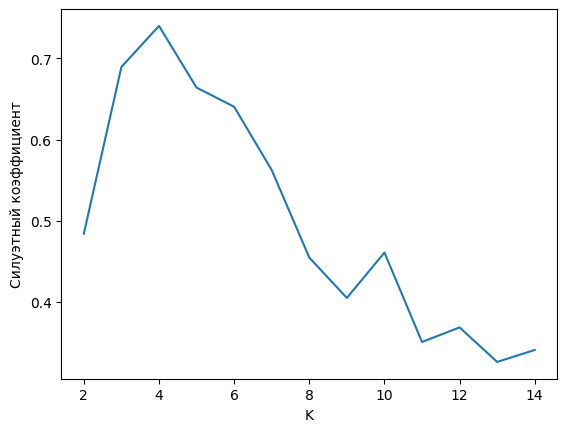

In [153]:
plt.plot(range(2, 15), silhouette_scores)
plt.xlabel("K")
plt.ylabel('Силуэтный коэффициент')
plt.show()

In [154]:
gm = GaussianMixture(n_components=4).fit(X_2)

In [155]:
gm.predict(X_2)

array([1, 2, 1, 0, 2, 1, 1, 1, 3, 3, 1, 1, 0, 3, 0, 3, 1, 1, 3, 2, 0, 3,
       2, 2, 0, 1, 0, 3, 1, 1, 0, 2, 1, 2, 1, 0, 3, 1, 3, 1, 0, 1, 2, 1,
       1, 1, 1, 0, 2, 1, 3, 2, 3, 2, 2, 2, 2, 1, 3, 3, 3, 1, 3, 1, 1, 1,
       2, 3, 3, 2, 2, 3, 1, 0, 3, 2, 1, 0, 2, 1, 3, 1, 1, 0, 1, 2, 0, 1,
       2, 0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 1, 3, 1, 1, 3, 3, 2, 1, 3, 2, 1,
       0, 3, 3, 2, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 1, 0, 3, 1, 0, 2, 0,
       1, 2, 1, 1, 2, 2, 1, 0, 1, 1, 1, 2, 0, 2, 0, 3, 0, 1, 2, 1, 0, 1,
       1, 3, 1, 1, 3, 3, 1, 0, 0, 1, 1, 3, 3, 2, 1, 1, 0, 3, 1, 2, 3, 1,
       1, 3, 0, 2, 1, 1, 1, 1, 1, 2, 1, 3, 0, 1, 1, 0, 1, 3, 0, 1, 1, 1,
       0, 1, 0, 1, 2, 0, 1, 3, 3, 1, 1, 2, 1, 2, 0, 0, 2, 1, 1, 1, 0, 2,
       1, 1, 1, 1, 3, 3, 0, 2, 0, 0, 3, 1, 0, 3, 3, 3, 0, 3, 1, 3, 0, 1,
       1, 0, 1, 2, 0, 0, 3, 3, 0, 2, 3, 0, 1, 0, 1, 3, 1, 3, 2, 0, 1, 0,
       3, 3, 1, 0, 0, 1, 1, 1, 1, 1, 2, 1, 3, 1, 2, 2, 1, 1, 2, 2, 2, 1,
       0, 1, 0, 2, 3, 2, 1, 3, 2, 3, 0, 3, 1, 1])

In [156]:
silhouette_score(X_2, gm.predict(X_2))

0.7399572903221314

## AffinityPropagation